# **노래 탐색적 분석**

앞선 분석과 같이 주요 지표로 꼽은 지표는 노래에서는 track_popularity를 통해 다른 지표들과의 관계성을 탐구하는 방향으로 탐색적 분석을 시작하겠습니다.

**acousticness**

컬럼 설명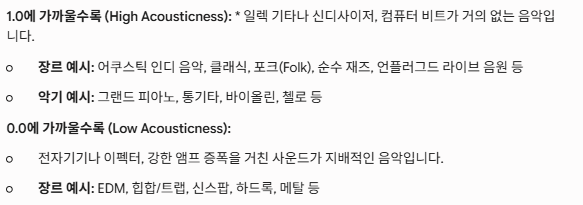

## **1. 기본적인 분포 및 통계량 분석**

### 1.1 기초 통계

In [1]:
import pandas as pd

df = pd.read_csv('song.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1437 entries, 0 to 1436
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   energy            1437 non-null   float64
 1   tempo             1437 non-null   float64
 2   danceability      1437 non-null   float64
 3   loudness          1437 non-null   float64
 4   liveness          1437 non-null   float64
 5   valence           1437 non-null   float64
 6   track_artist      1437 non-null   object 
 7   time_signature    1437 non-null   int64  
 8   speechiness       1437 non-null   float64
 9   track_popularity  1437 non-null   int64  
 10  uri               1437 non-null   object 
 11  track_id          1437 non-null   object 
 12  track_name        1437 non-null   object 
 13  instrumentalness  1437 non-null   float64
 14  mode              1437 non-null   int64  
 15  key               1437 non-null   int64  
 16  duration_ms       1437 non-null   int64  


결측값은 존재하지 않음

In [4]:
df['track_popularity'].describe()

,track_popularity
count,1437.000000
mean,75.249130
std,5.574815
min,68.000000
25%,71.000000
50%,74.000000
75%,79.000000
max,100.000000


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


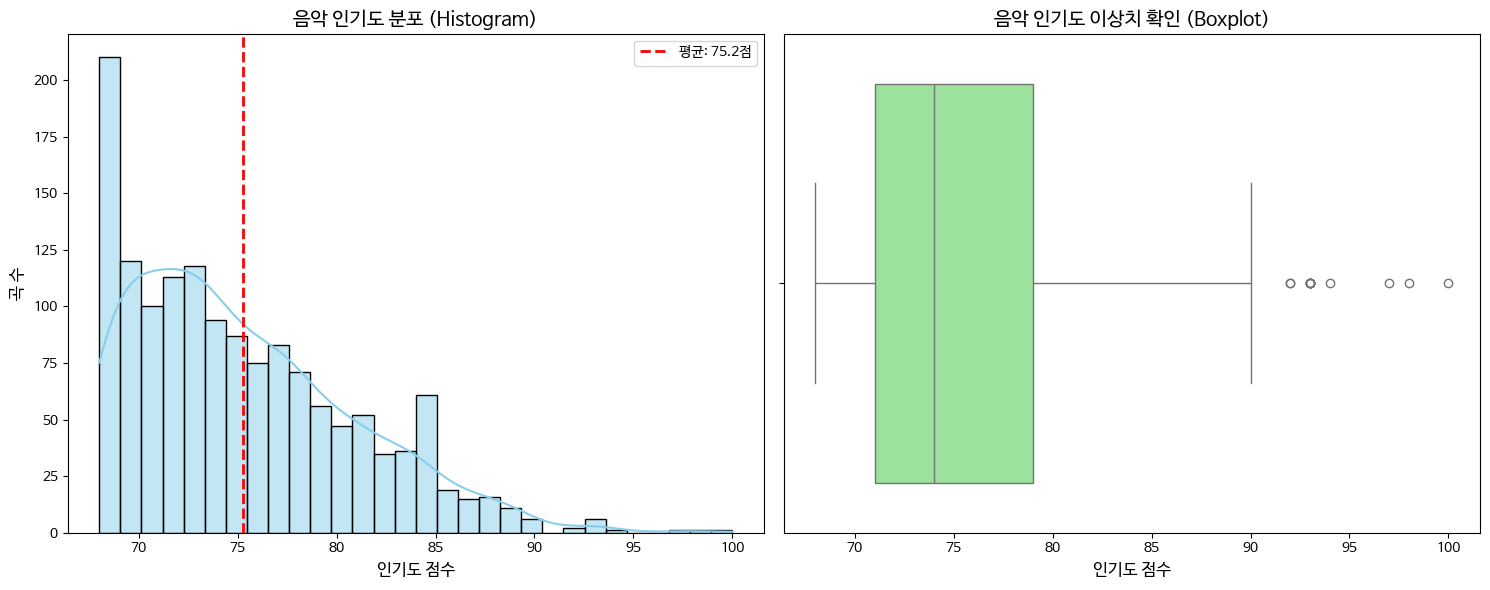

--------------------------------------------------
📊 [인기도 0점 데이터 분석 결과]
• 전체 데이터 수: 1437개
• 인기도가 0인 곡: 0개
• 전체 곡 중 비율: 0.00%
--------------------------------------------------


In [7]:
# 1. 한글 폰트 설치 및 폰트 캐시 리빌드
!apt-get update -qq
!apt-get install fonts-nanum -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

# 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# 2. 설치된 나눔 폰트를 matplotlib 폰트 매니저에 직접 등록 (오류 방지)
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 시각화 진행 (1행 2열 구조)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# [왼쪽 그래프] 히스토그램 (Histogram)
sns.histplot(data=df, x='track_popularity', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('음악 인기도 분포 (Histogram)', fontsize=14)
axes[0].set_xlabel('인기도 점수', fontsize=12)
axes[0].set_ylabel('곡 수', fontsize=12)

# 평균값 계산 및 점선 표시
pop_mean = df['track_popularity'].mean()
axes[0].axvline(pop_mean, color='red', linestyle='--', linewidth=2, label=f"평균: {pop_mean:.1f}점")
axes[0].legend()

# [오른쪽 그래프] 박스플롯 (Boxplot)
sns.boxplot(data=df, x='track_popularity', ax=axes[1], color='lightgreen')
axes[1].set_title('음악 인기도 이상치 확인 (Boxplot)', fontsize=14)
axes[1].set_xlabel('인기도 점수', fontsize=12)

# 그래프 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

# 4. 인기도 0인 곡 수 및 비율 계산 후 출력
zero_pop_count = (df['track_popularity'] == 0).sum()
zero_pop_ratio = (zero_pop_count / len(df)) * 100

print("-" * 50)
print(f"📊 [인기도 0점 데이터 분석 결과]")
print(f"• 전체 데이터 수: {len(df)}개")
print(f"• 인기도가 0인 곡: {zero_pop_count}개")
print(f"• 전체 곡 중 비율: {zero_pop_ratio:.2f}%")
print("-" * 50)

평균은 대략 75점 정도이며, 높아질수록 적어지는 특징을 가짐

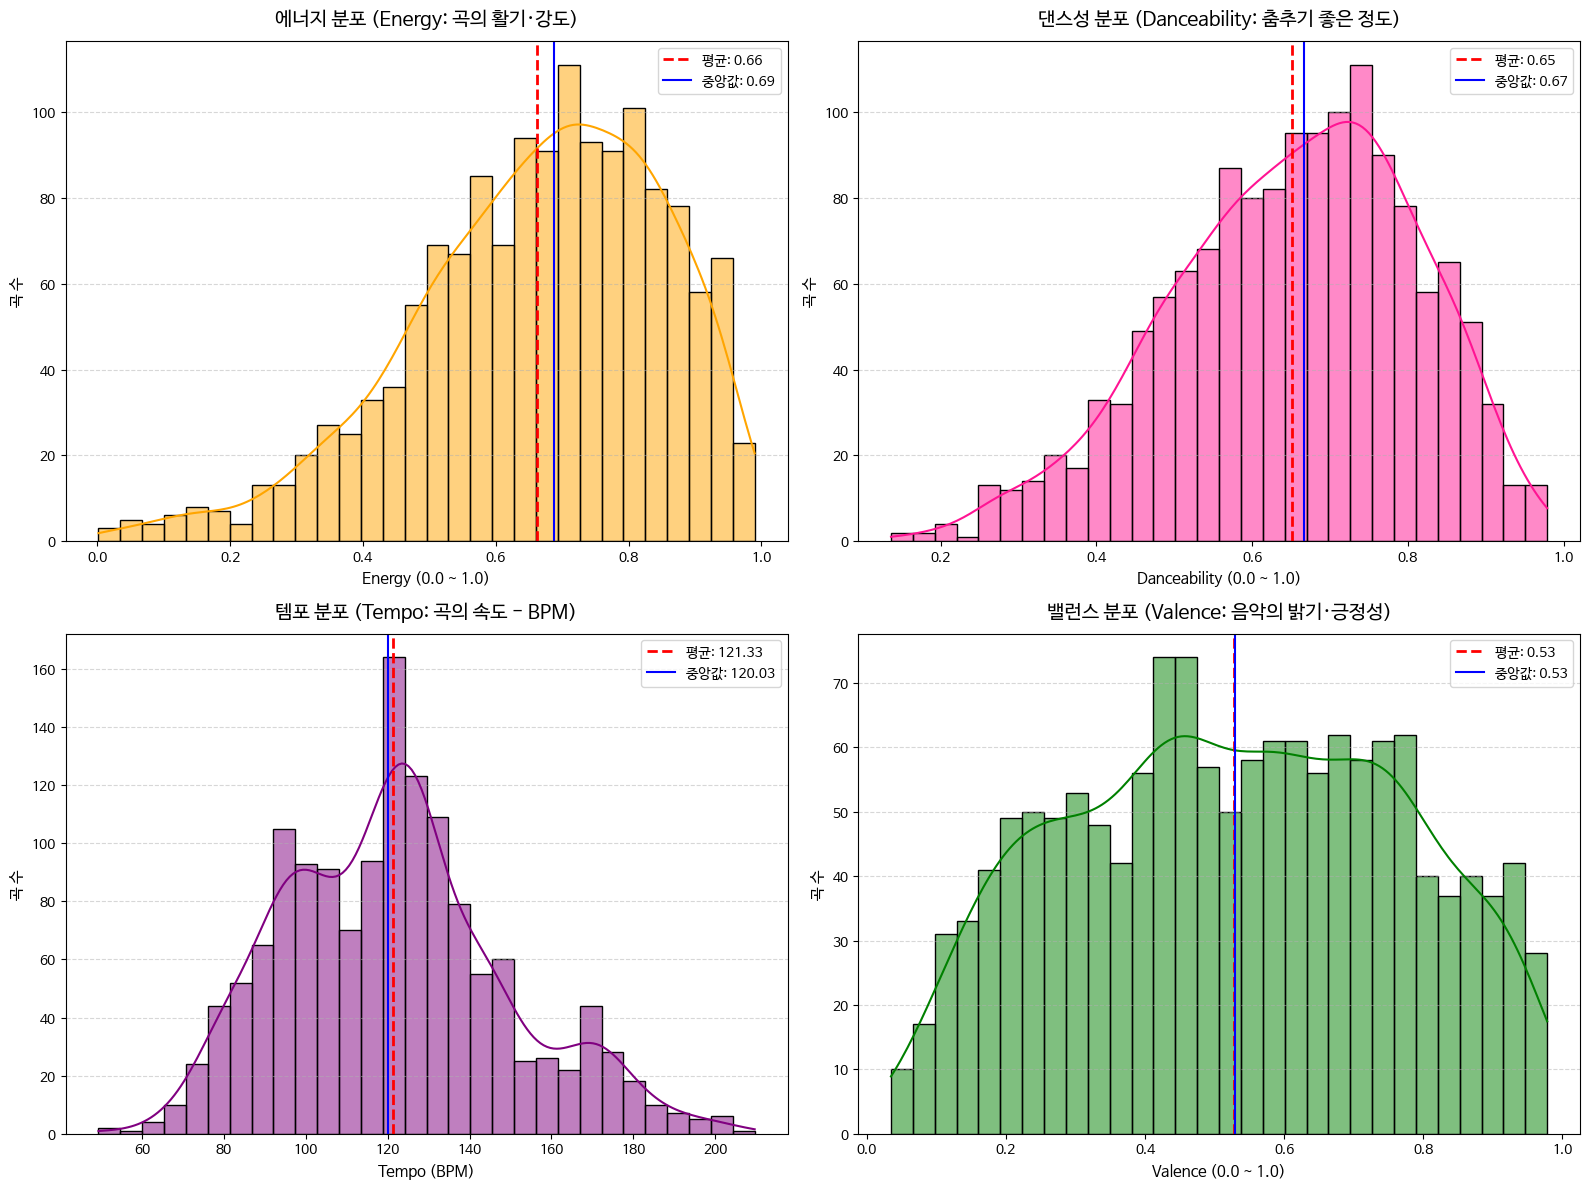

------------------------------------------------------------
🎵 [주요 오디오 특성 평균값 기반 데이터셋 성격 진단]
• 평균 에너지(Energy): 0.66
• 평균 댄스성(Danceability): 0.65
• 평균 템포(Tempo): 121.3 BPM
• 평균 밸런스(Valence): 0.53
------------------------------------------------------------


In [12]:
# 2x2 서브플롯 형태로 시각화 틀 만들기
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 분석할 오디오 특성 리스트와 올바른 색상(deeppink) 설정
features = ['energy', 'danceability', 'tempo', 'valence']
colors = ['orange', 'deeppink', 'purple', 'green']
titles = [
    '에너지 분포 (Energy: 곡의 활기·강도)',
    '댄스성 분포 (Danceability: 춤추기 좋은 정도)',
    '템포 분포 (Tempo: 곡의 속도 - BPM)',
    '밸런스 분포 (Valence: 음악의 밝기·긍정성)'
]
x_labels = ['Energy (0.0 ~ 1.0)', 'Danceability (0.0 ~ 1.0)', 'Tempo (BPM)', 'Valence (0.0 ~ 1.0)']

# 4개의 그래프를 반복문으로 순회하며 그리기
for i, col in enumerate(features):
    row_idx = i // 2
    col_idx = i % 2
    ax = axes[row_idx, col_idx]

    # 히스토그램 + 커널밀도추정(KDE) 곡선
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=ax, color=colors[i], alpha=0.5)

    # 평균값(빨간 점선)과 중앙값(파란 실선) 표시하여 왜도(Skewness) 파악
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_val:.2f}')
    ax.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label=f'중앙값: {median_val:.2f}')

    ax.set_title(titles[i], fontsize=14, pad=12)
    ax.set_xlabel(x_labels[i], fontsize=11)
    ax.set_ylabel('곡 수', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 그래프 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

# --- 데이터셋 성격 규정을 위한 간단 요약 통계 출력 ---
print("-" * 60)
print("🎵 [주요 오디오 특성 평균값 기반 데이터셋 성격 진단]")
print(f"• 평균 에너지(Energy): {df['energy'].mean():.2f}")
print(f"• 평균 댄스성(Danceability): {df['danceability'].mean():.2f}")
print(f"• 평균 템포(Tempo): {df['tempo'].mean():.1f} BPM")
print(f"• 평균 밸런스(Valence): {df['valence'].mean():.2f}")
print("-" * 60)

모든 데이터가 정규 분포의 형태를 띄고 있음을 알 수 있음

## **2. 시계열 및 트렌드 분석 (Temporal/Structural Analysis)**

### 2.1 곡 길이(duration_ms) 트렌드 분석

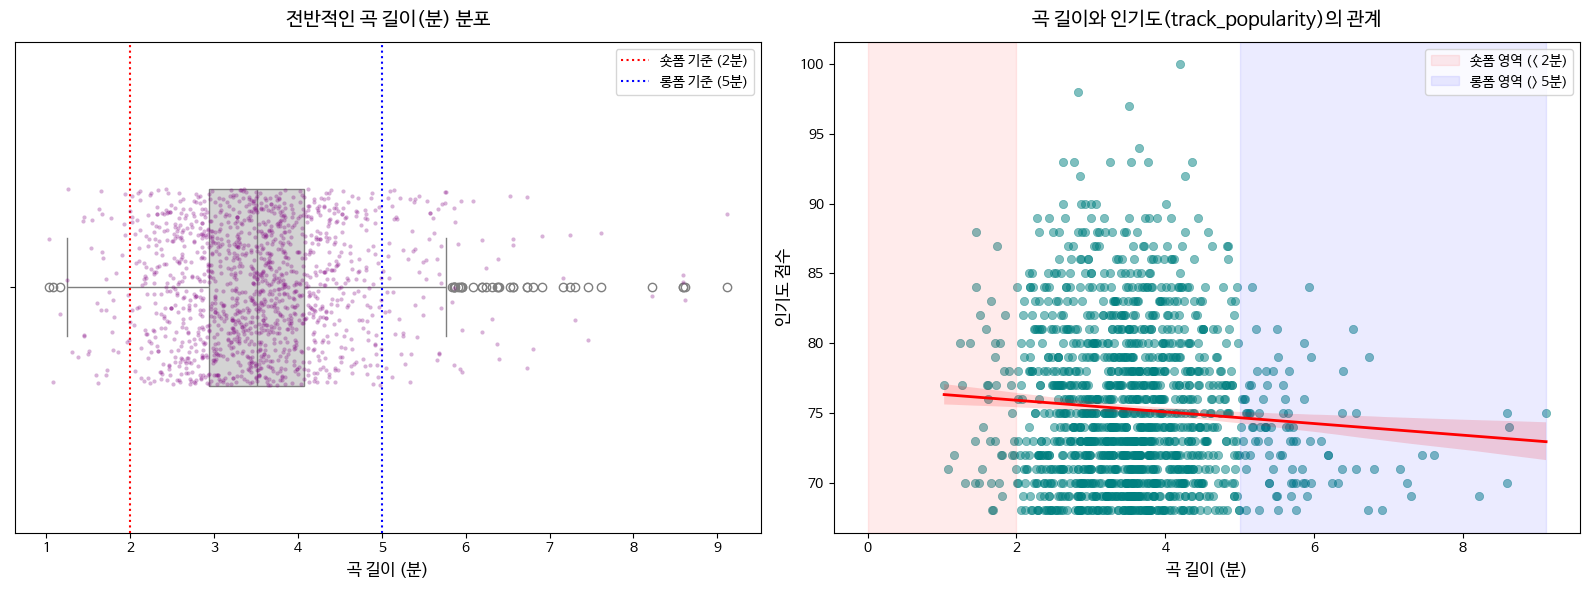

-----------------------------------------------------------------
⏱️ [곡 길이 그룹별 인기도 통계 요약]
• 숏폼 곡 (2분 미만)   : 총  43개 | 평균 인기도: 75.56점
• 일반 곡 (2분~5분 사이): 총 1297개 | 평균 인기도: 75.37점
• 롱폼 곡 (5분 초과)   : 총  97개 | 평균 인기도: 73.51점
-----------------------------------------------------------------


In [13]:
# 1. 밀리초(ms) 데이터를 분(Minutes) 단위 변환 파생 변수 생성
# (1초 = 1000ms, 1분 = 60초이므로 60,000으로 나눔)
df['duration_min'] = df['duration_ms'] / 60000

# 2. 시각화를 위한 1행 2열 프레임 생성
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# [왼쪽 그래프] 곡 길이 분포 확인 (Boxplot + Stripplot 개별 곡 분포 레이어)
sns.boxplot(data=df, x='duration_min', ax=axes[0], color='lightgray', width=0.4)
sns.stripplot(data=df, x='duration_min', ax=axes[0], color='purple', size=3, alpha=0.3, jitter=0.2)
axes[0].set_title('전반적인 곡 길이(분) 분포', fontsize=14, pad=12)
axes[0].set_xlabel('곡 길이 (분)', fontsize=12)

# 주요 기준점 가이드라인 표시 (2분 미만 숏폼, 5분 이상 롱폼)
axes[0].axvline(2.0, color='red', linestyle=':', linewidth=1.5, label='숏폼 기준 (2분)')
axes[0].axvline(5.0, color='blue', linestyle=':', linewidth=1.5, label='롱폼 기준 (5분)')
axes[0].legend()

# [오른쪽 그래프] 곡 길이와 인기도의 관계 (Scatter Plot)
sns.scatterplot(data=df, x='duration_min', y='track_popularity', ax=axes[1], color='teal', alpha=0.5, edgecolor=None)
# 경향성을 보기 위한 회귀선(Trend Line) 추가
sns.regplot(data=df, x='duration_min', y='track_popularity', ax=axes[1], scatter=False, color='red', line_kws={'linewidth': 2})

axes[1].set_title('곡 길이와 인기도(track_popularity)의 관계', fontsize=14, pad=12)
axes[1].set_xlabel('곡 길이 (분)', fontsize=12)
axes[1].set_ylabel('인기도 점수', fontsize=12)

# 특이 구간 음영 처리
axes[1].axvspan(0, 2.0, color='red', alpha=0.08, label='숏폼 영역 (< 2분)')
axes[1].axvspan(5.0, df['duration_min'].max(), color='blue', alpha=0.08, label='롱폼 영역 (> 5분)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. 숏폼 vs 일반 vs 롱폼 그룹별 요약 통계 출력
short_form = df[df['duration_min'] < 2.0]
normal_form = df[(df['duration_min'] >= 2.0) & (df['duration_min'] <= 5.0)]
long_form = df[df['duration_min'] > 5.0]

print("-" * 65)
print("⏱️ [곡 길이 그룹별 인기도 통계 요약]")
print(f"• 숏폼 곡 (2분 미만)   : 총 {len(short_form):3}개 | 평균 인기도: {short_form['track_popularity'].mean():.2f}점")
print(f"• 일반 곡 (2분~5분 사이): 총 {len(normal_form):3}개 | 평균 인기도: {normal_form['track_popularity'].mean():.2f}점")
print(f"• 롱폼 곡 (5분 초과)   : 총 {len(long_form):3}개 | 평균 인기도: {long_form['track_popularity'].mean():.2f}점")
print("-" * 65)

해당 그래프에 대해 설명하자면, 왼쪽은 곡을 모두 산점도로 찍고, 인기도를 y축으로 두어 전체적인 분포를 확인하는 그래프.

오른쪽 그래프는 전체 곡을 마찬가지로 산점도를 찍고 회귀선을 곡 길이와 인기도의 연관성을 왼쪽 그래프에 비해 직접적으로 확인하고자 함

완만한 우하향 회귀선: 빨간색 트렌드 라인이 오른쪽으로 갈수록 완만하게 떨어지는 흐름을 보입니다. 즉, "곡이 길어질수록 대중적인 인기도 점수는 낮아지는 경향이 있다"는 가설이 통계적으로 성립합니다.

더 자세한 관찰을 위해, 회귀선을 다항회귀로 진행해서 더 구체적인 추세를 확인.

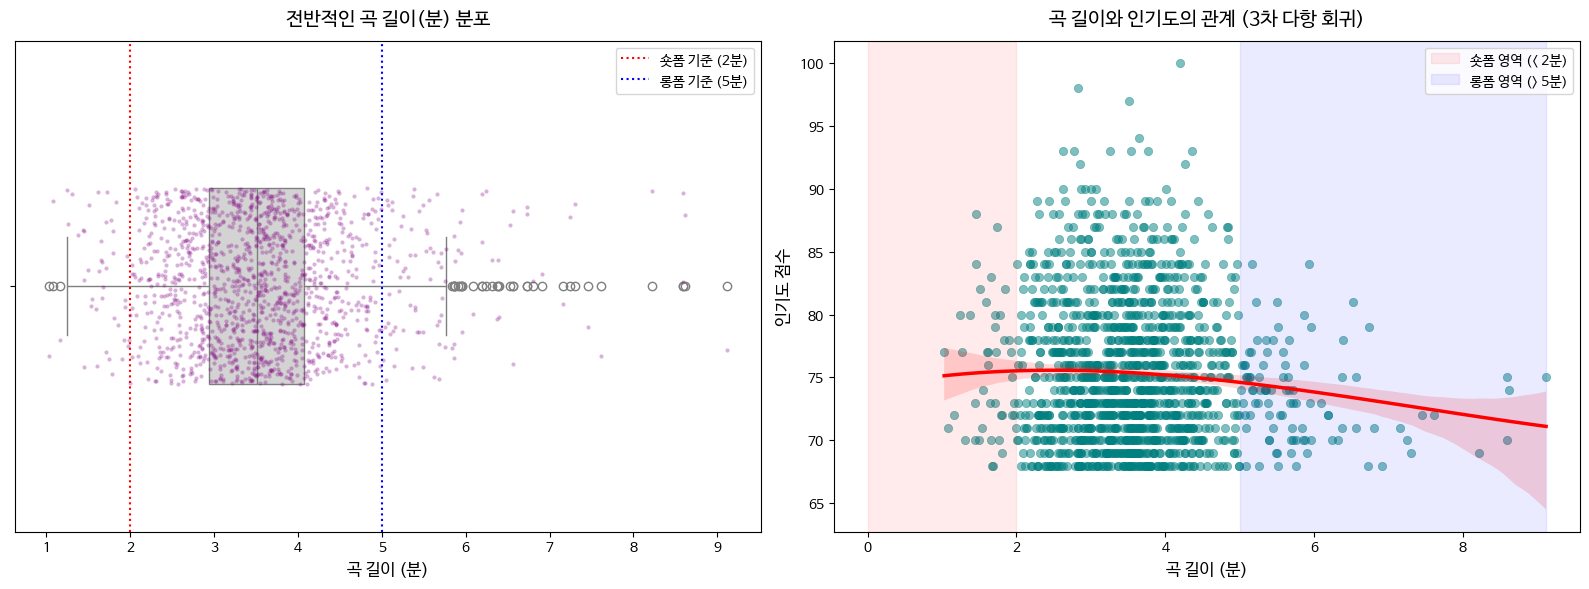

In [14]:
# 시각화를 위한 1행 2열 프레임 생성
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# [왼쪽 그래프] 곡 길이 분포 확인 (기존 동일)
sns.boxplot(data=df, x='duration_min', ax=axes[0], color='lightgray', width=0.4)
sns.stripplot(data=df, x='duration_min', ax=axes[0], color='purple', size=3, alpha=0.3, jitter=0.2)
axes[0].set_title('전반적인 곡 길이(분) 분포', fontsize=14, pad=12)
axes[0].set_xlabel('곡 길이 (분)', fontsize=12)
axes[0].axvline(2.0, color='red', linestyle=':', linewidth=1.5, label='숏폼 기준 (2분)')
axes[0].axvline(5.0, color='blue', linestyle=':', linewidth=1.5, label='롱폼 기준 (5분)')
axes[0].legend()

# [오른쪽 그래프] 곡 길이와 인기도의 관계 (3차 다항 회귀 적용)
sns.scatterplot(data=df, x='duration_min', y='track_popularity', ax=axes[1], color='teal', alpha=0.5, edgecolor=None)

# 💡 order=3 옵션으로 3차 다항 회귀선 그리기 (선명한 붉은색 곡선)
sns.regplot(
    data=df,
    x='duration_min',
    y='track_popularity',
    order=3,
    ax=axes[1],
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5, 'label': '3차 다항 회귀 추세선'}
)

axes[1].set_title('곡 길이와 인기도의 관계 (3차 다항 회귀)', fontsize=14, pad=12)
axes[1].set_xlabel('곡 길이 (분)', fontsize=12)
axes[1].set_ylabel('인기도 점수', fontsize=12)

# 특이 구간 음영 처리
axes[1].axvspan(0, 2.0, color='red', alpha=0.08, label='숏폼 영역 (< 2분)')
axes[1].axvspan(5.0, df['duration_min'].max(), color='blue', alpha=0.08, label='롱폼 영역 (> 5분)')
axes[1].legend()

plt.tight_layout()
plt.show()

3차 방정식으로 확인한 결과 3분의 곡이 가장 대중적으로 인기가 좋고,
짧아지는 것은 그에 비해 완만하게 인기도가 감소하나, 길어지는 것은 그보다 급격히 감소함.

### 2.2 템포 및 박자 분석

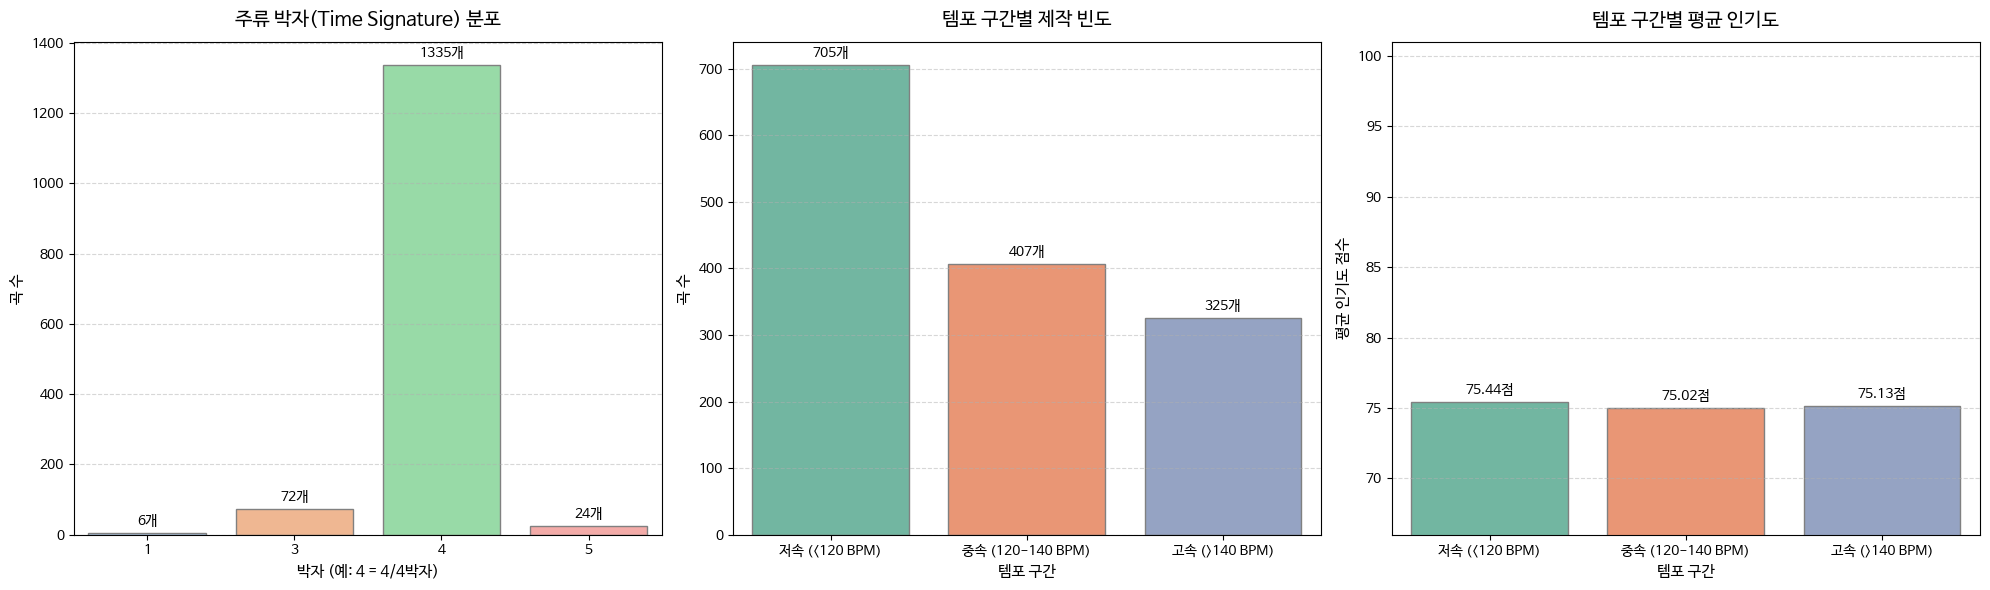

-----------------------------------------------------------------
🥁 [템포 구간별 상세 흥행 데이터]
• 저속 (<120 BPM)   | 곡 수: 705개 | 평균 인기도: 75.44점
• 중속 (120-140 BPM) | 곡 수: 407개 | 평균 인기도: 75.02점
• 고속 (>140 BPM)   | 곡 수: 325개 | 평균 인기도: 75.13점
-----------------------------------------------------------------


In [15]:
import numpy as np

# 1. 템포(BPM) 구간 나누기 (저속, 중속, 고속) 파생 변수 생성
conditions = [
    (df['tempo'] < 120),
    (df['tempo'] >= 120) & (df['tempo'] <= 140),
    (df['tempo'] > 140)
]
choices = ['저속 (<120 BPM)', '중속 (120-140 BPM)', '고속 (>140 BPM)']
df['tempo_group'] = np.select(conditions, choices, default='Unknown')

# 정렬 순서 고정 (저속 -> 중속 -> 고속)
tempo_order = ['저속 (<120 BPM)', '중속 (120-140 BPM)', '고속 (>140 BPM)']

# 2. 시각화를 위한 1행 3열 프레임 생성
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# [왼쪽 그래프] 박자(time_signature) 분포 (Count Plot)
sns.countplot(data=df, x='time_signature', ax=axes[0], palette='pastel', edgecolor='gray')
axes[0].set_title('주류 박자(Time Signature) 분포', fontsize=14, pad=12)
axes[0].set_xlabel('박자 (예: 4 = 4/4박자)', fontsize=11)
axes[0].set_ylabel('곡 수', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 박자 차트 위에 개수(Count) 텍스트 표시
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}개', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')


# [가운데 그래프] 템포 구간별 제작 빈도 (Count Plot)
sns.countplot(data=df, x='tempo_group', order=tempo_order, ax=axes[1], palette='Set2', edgecolor='gray')
axes[1].set_title('템포 구간별 제작 빈도', fontsize=14, pad=12)
axes[1].set_xlabel('템포 구간', fontsize=11)
axes[1].set_ylabel('곡 수', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}개', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')


# [오른쪽 그래프] 템포 구간별 평균 인기도 비교 (Bar Plot)
# 신뢰구간(error bar)은 빼고 순수 평균값만 직관적으로 비교
sns.barplot(data=df, x='tempo_group', y='track_popularity', order=tempo_order, ax=axes[2], palette='Set2', ci=None, edgecolor='gray')
axes[2].set_title('템포 구간별 평균 인기도', fontsize=14, pad=12)
axes[2].set_xlabel('템포 구간', fontsize=11)
axes[2].set_ylabel('평균 인기도 점수', fontsize=11)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

# 인기도 점수가 박스 상단에 표시되도록 설정 (Y축 범위 살짝 조정)
axes[2].set_ylim(df['track_popularity'].min() - 2, df['track_popularity'].max() + 1)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.2f}점', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. 상세 수치 통계 출력
print("-" * 65)
print("🥁 [템포 구간별 상세 흥행 데이터]")
for group in tempo_order:
    sub_df = df[df['tempo_group'] == group]
    print(f"• {group:15} | 곡 수: {len(sub_df):3}개 | 평균 인기도: {sub_df['track_popularity'].mean():.2f}점")
print("-" * 65)

템포에 따른 인기도의 유의미한 차이는 없음


## **3. 범주형 및 아티스트 분석 (Categorical & Artist Analysis)**

### 3.1 장르(genre)별 파워 분석

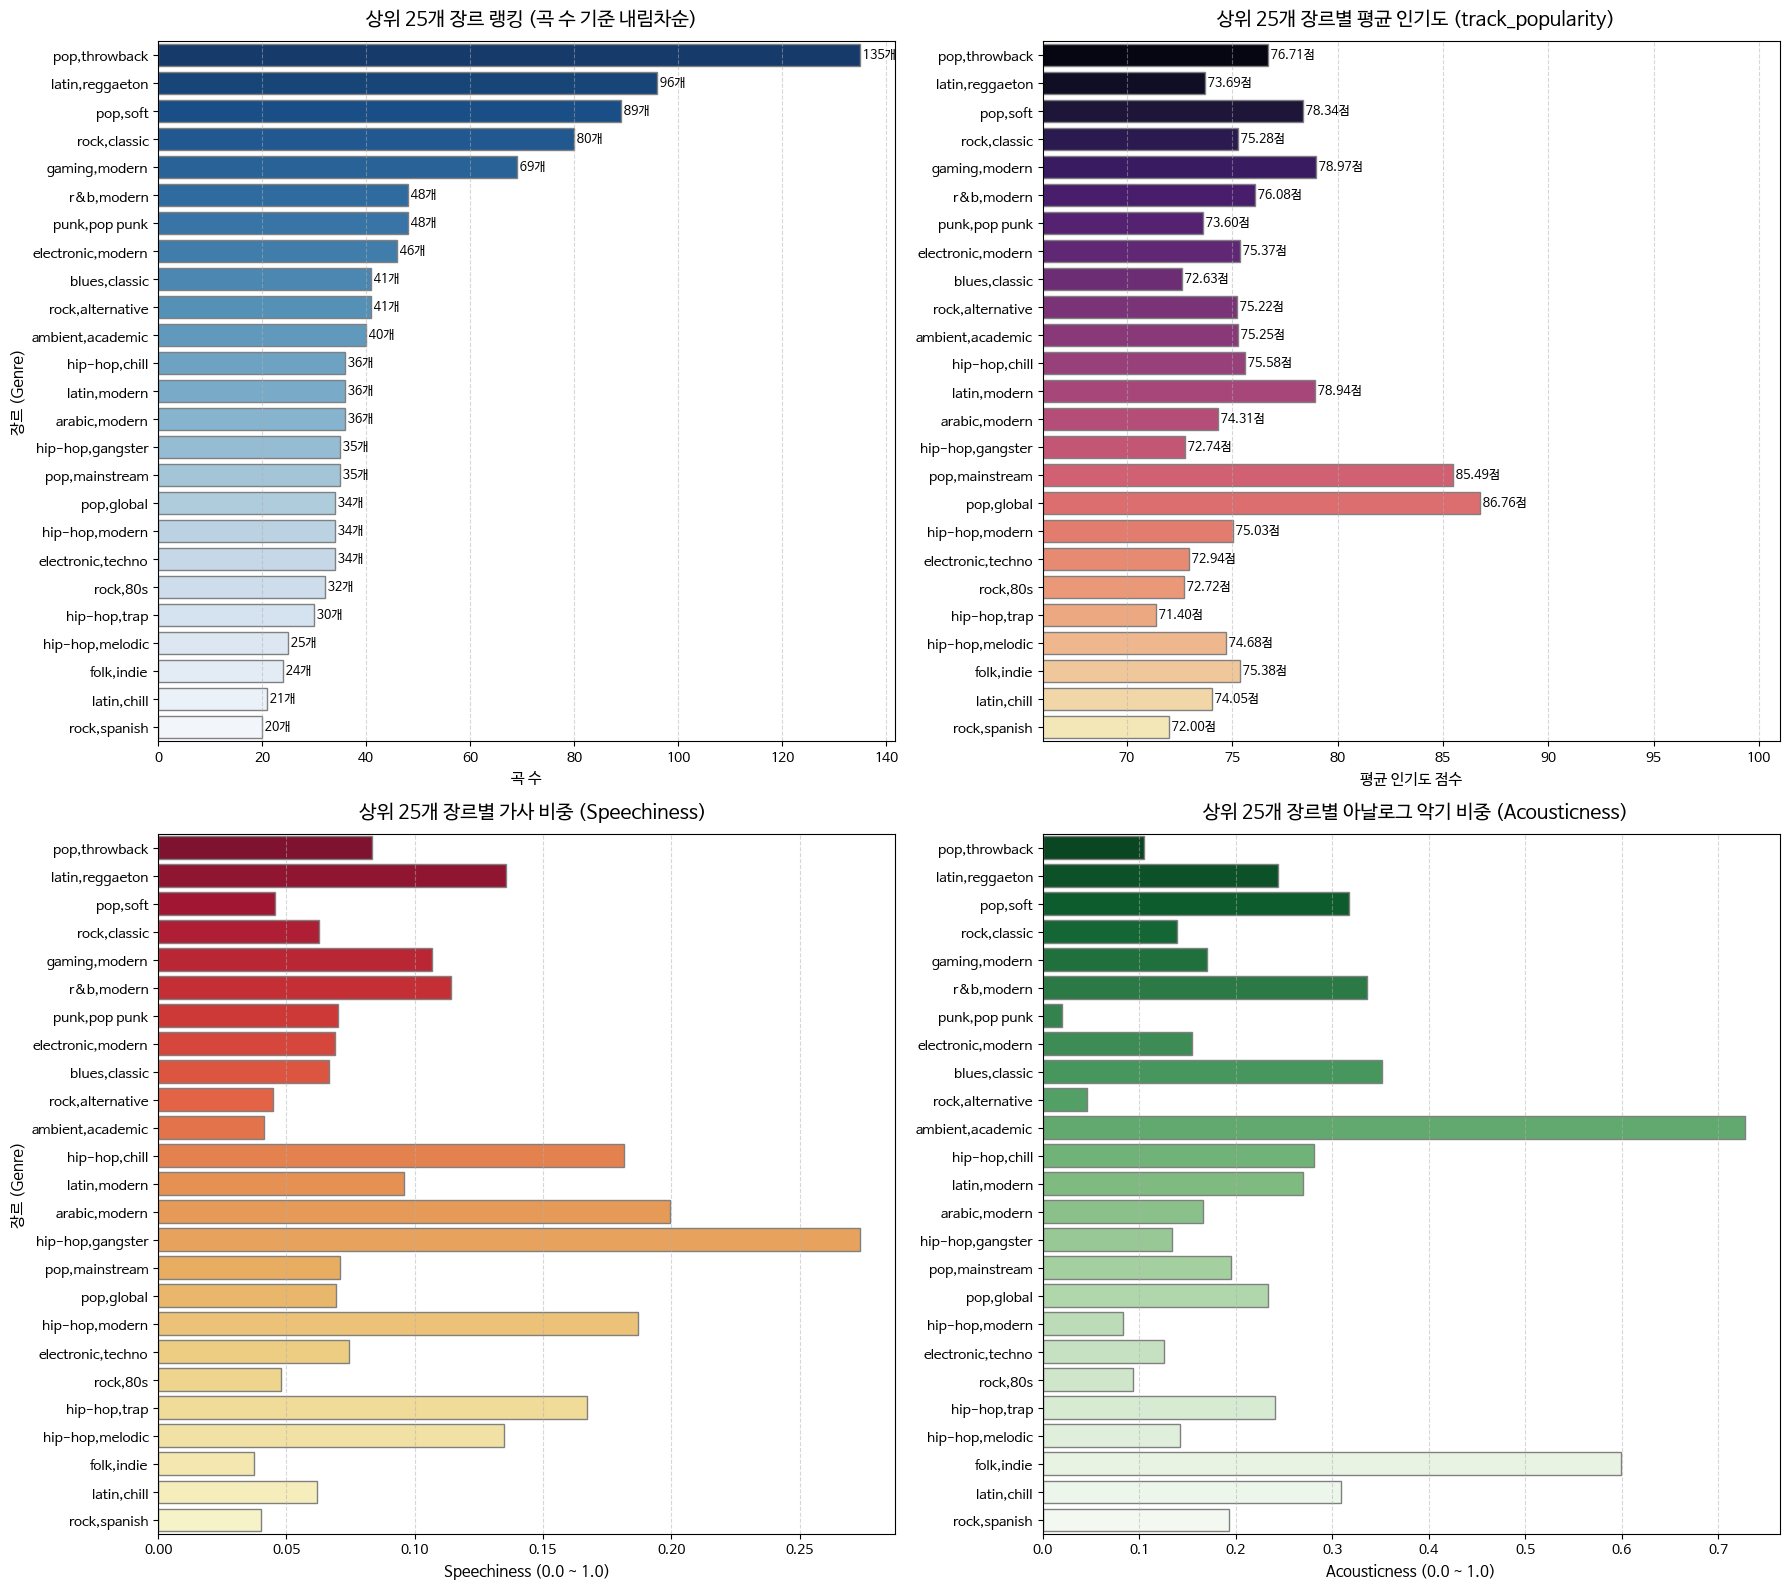

--------------------------------------------------------------------------------
📊 [상위 25개 장르별 핵심 지표 요약 리포트]
                   곡 수  track_popularity  speechiness  acousticness
genre                                                              
pop,throwback      135            76.711        0.083         0.105
latin,reggaeton     96            73.688        0.135         0.244
pop,soft            89            78.337        0.045         0.317
rock,classic        80            75.275        0.063         0.139
gaming,modern       69            78.971        0.107         0.170
r&b,modern          48            76.083        0.114         0.336
punk,pop punk       48            73.604        0.070         0.020
electronic,modern   46            75.370        0.069         0.155
blues,classic       41            72.634        0.066         0.351
rock,alternative    41            75.220        0.045         0.046
ambient,academic    40            75.250        0.041         0.727
hip-hop

In [19]:
# 1. 장르별 빈도를 계산하여 상위 25개 장르만 추출 및 내림차순 정렬 순서 정의
top_25_genres = df['genre'].value_counts().head(25).index

# 상위 25개 장르 데이터만 필터링
df_top25 = df[df['genre'].isin(top_25_genres)]

# 2. 시각화를 위한 2행 2열 프레임 생성 (데이터가 많아졌으므로 세로 길이를 16으로 확장)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 16))
axes = axes.flatten()

# [그래프 1] 장르별 곡 수 (상위 25개 매스 장르 랭킹)
sns.countplot(data=df_top25, y='genre', order=top_25_genres, ax=axes[0], palette='Blues_r', edgecolor='gray')
axes[0].set_title('🥇 상위 25개 장르 랭킹 (곡 수 기준 내림차순)', fontsize=14, pad=12)
axes[0].set_xlabel('곡 수', fontsize=11)
axes[0].set_ylabel('장르 (Genre)', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# 바 옆에 개수 표시
for p in axes[0].patches:
    axes[0].annotate(f' {int(p.get_width())}개', (p.get_width(), p.get_y() + p.get_height()/2.),
                ha='left', va='center', fontsize=9, fontweight='bold')


# [그래프 2] 장르별 평균 인기도 비교 (곡 수 순서대로 배치)
sns.barplot(data=df_top25, y='genre', x='track_popularity', order=top_25_genres, ax=axes[1], palette='magma', ci=None, edgecolor='gray')
axes[1].set_title('🔥 상위 25개 장르별 평균 인기도 (track_popularity)', fontsize=14, pad=12)
axes[1].set_xlabel('평균 인기도 점수', fontsize=11)
axes[1].set_ylabel('', fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# 인기도 기준 하한선 조정하여 시각적 차이 부각
pop_min = df_top25['track_popularity'].min()
axes[1].set_xlim(pop_min - 2, df_top25['track_popularity'].max() + 1)
for p in axes[1].patches:
    axes[1].annotate(f' {p.get_width():.2f}점', (p.get_width(), p.get_y() + p.get_height()/2.),
                ha='left', va='center', fontsize=9, fontweight='bold')


# [그래프 3] 장르별 가사 비중 (곡 수 순서대로 배치)
sns.barplot(data=df_top25, y='genre', x='speechiness', order=top_25_genres, ax=axes[2], palette='YlOrRd_r', ci=None, edgecolor='gray')
axes[2].set_title('🗣️ 상위 25개 장르별 가사 비중 (Speechiness)', fontsize=14, pad=12)
axes[2].set_xlabel('Speechiness (0.0 ~ 1.0)', fontsize=11)
axes[2].set_ylabel('장르 (Genre)', fontsize=11)
axes[2].grid(axis='x', linestyle='--', alpha=0.5)


# [그래프 4] 장르별 아날로그 질감 (곡 수 순서대로 배치)
sns.barplot(data=df_top25, y='genre', x='acousticness', order=top_25_genres, ax=axes[3], palette='Greens_r', ci=None, edgecolor='gray')
axes[3].set_title('🎸 상위 25개 장르별 아날로그 악기 비중 (Acousticness)', fontsize=14, pad=12)
axes[3].set_xlabel('Acousticness (0.0 ~ 1.0)', fontsize=11)
axes[3].set_ylabel('', fontsize=11)
axes[3].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. 상위 25개 장르 요약 데이터 프레임 출력
print("-" * 80)
print("📊 [상위 25개 장르별 핵심 지표 요약 리포트]")
summary_df = df_top25.groupby('genre').agg({
    'track_id': 'count',
    'track_popularity': 'mean',
    'speechiness': 'mean',
    'acousticness': 'mean'
}).rename(columns={'track_id': '곡 수'}).loc[top_25_genres]
print(summary_df.round(3))
print("-" * 80)

독보적인 인기도 점수: pop, global(86.7점)과 pop, mainstream(85.4점)은 곡 수 자체는 34~35개로 중간 순위지만, 인기도 점수에서 다른 모든 장르를 압도하는 80점대 중후반을 기록 중입니다.

흥행 공식: 이 장르들은 가사 비중(speechiness 0.07 전후)이 과하지 않고, 아날로그 질감(acousticness 0.19~0.23)도 적당히 섞여 있습니다. 즉, 보컬 위주의 대중적인 멜로디에 트렌디한 사운드를 얹은 곡

가사(Rap/Lyrics) 중심의 장르: * hip-hop, gangster(0.274), arabic, modern(0.199), hip-hop, modern(0.187), hip-hop, chill(0.181) 순으로 speechiness가 압도적으로 높습니다. 비트 위에 랩이나 말소리 비중이 큰 장르적 특성이 고스란히 반영되었습니다. 특히 갱스터 힙합이 가장 거칠고 촘촘하게 가사를 뱉어내고 있네요.

아날로그/리얼 악기 중심의 장르: * ambient, academic(0.727)과 folk, indie(0.599)가 acousticness에서 압도적인 수치를 기록했습니다. 신디사이저나 강한 드럼 머신보다는 피아노, 통기타, 실제 현악기 등의 내추럴한 사운드가 중심이 되는 장르들입니다.

반면 punk, pop punk(0.020)나 rock, alternative(0.046)는 디스토션 걸린 일렉 기타와 강한 드럼 앰프를 사용하기 때문에 아날로그 수치가 바닥을 치는 흥미로운 대조를 보입니다.

이번에는 인기순으로 다시 보기

In [22]:
summary_df_sorted = summary_df.sort_values(by='track_popularity', ascending=False)
summary_df_sorted.round(3)

,곡 수,track_popularity,speechiness,acousticness
genre,,,,
"pop,global",34,86.765,0.069,0.234
"pop,mainstream",35,85.486,0.071,0.195
"gaming,modern",69,78.971,0.107,0.170
"latin,modern",36,78.944,0.096,0.270
"pop,soft",89,78.337,0.045,0.317
"pop,throwback",135,76.711,0.083,0.105
"r&b,modern",48,76.083,0.114,0.336
"hip-hop,chill",36,75.583,0.181,0.281
"folk,indie",24,75.375,0.037,0.599


### 3.2 노래 제목 분석

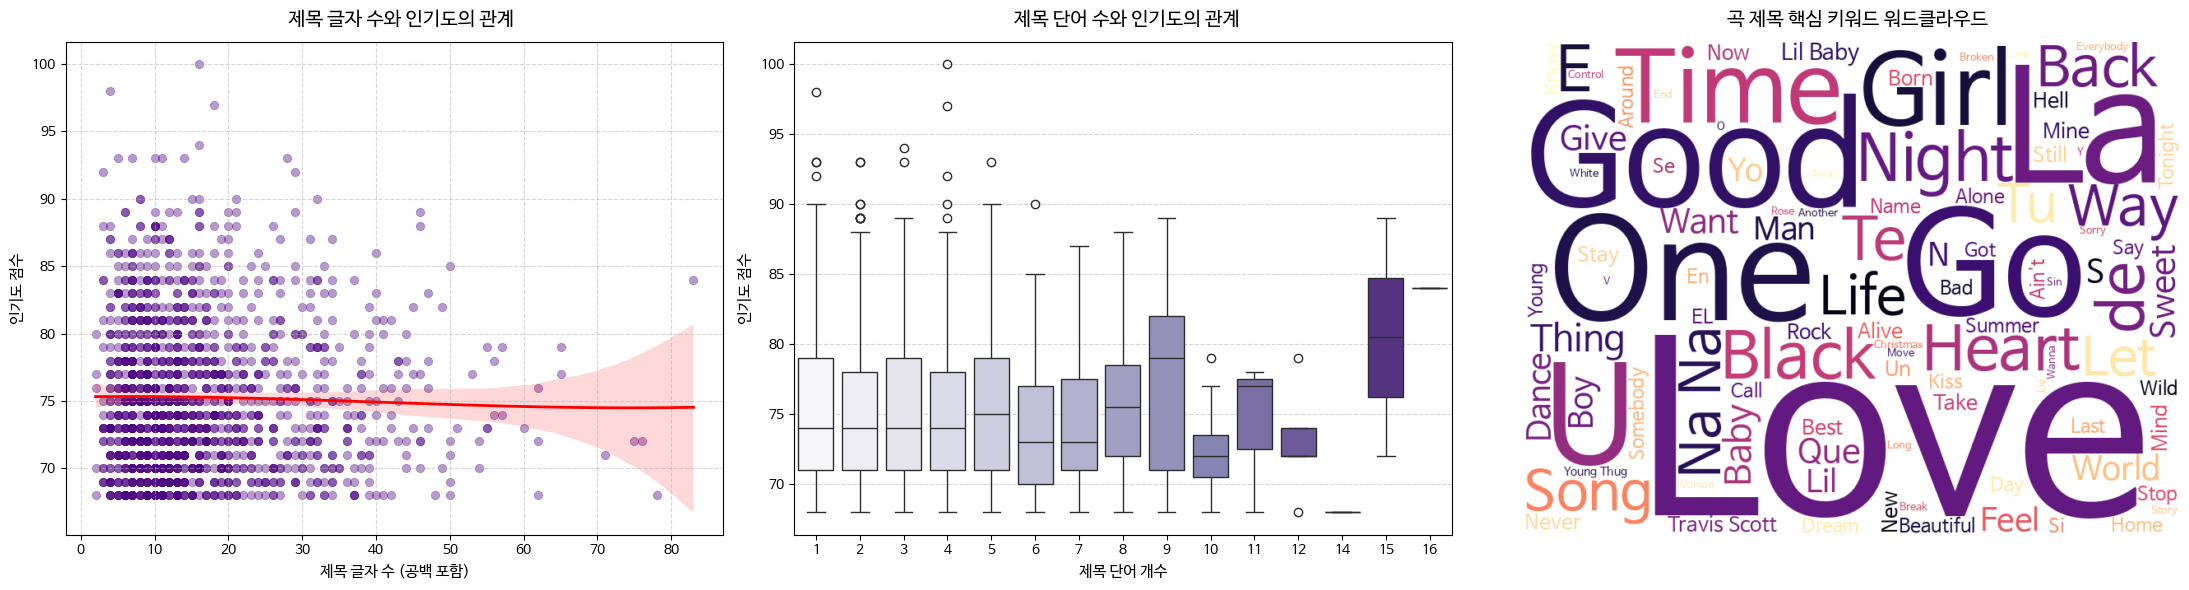

-----------------------------------------------------------------
📊 [곡 제목 텍스트 마이닝 통계 요약]
• 곡 제목 평균 글자 수: 16.5자
• 곡 제목 평균 단어 수: 3.2개
• 가장 긴 제목의 글자 수: 83자
-----------------------------------------------------------------


In [25]:
import numpy as np
from wordcloud import WordCloud, STOPWORDS

# 1. 곡 제목 기반 파생 변수 생성 (글자 수, 단어 수)
df['title_char_len'] = df['track_name'].astype(str).apply(len)
df['title_word_len'] = df['track_name'].astype(str).apply(lambda x: len(x.split()))

# 2. 시각화를 위한 프레임 생성 (1행 3열 구조)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

# [왼쪽 그래프] 제목 글자 수와 인기도의 관계 (3차 다항 회귀 적용)
sns.scatterplot(data=df, x='title_char_len', y='track_popularity', ax=axes[0], color='indigo', alpha=0.4, edgecolor=None)
sns.regplot(data=df, x='title_char_len', y='track_popularity', order=3, ax=axes[0], scatter=False, color='red', line_kws={'linewidth': 2})
axes[0].set_title('✍️ 제목 글자 수와 인기도의 관계', fontsize=14, pad=12)
axes[0].set_xlabel('제목 글자 수 (공백 포함)', fontsize=11)
axes[0].set_ylabel('인기도 점수', fontsize=11)
axes[0].grid(linestyle='--', alpha=0.5)

# [가운데 그래프] 제목 단어 수와 인기도의 관계 (Boxplot)
sns.boxplot(data=df, x='title_word_len', y='track_popularity', ax=axes[1], palette='Purples')
axes[1].set_title('📝 제목 단어 수와 인기도의 관계', fontsize=14, pad=12)
axes[1].set_xlabel('제목 단어 개수', fontsize=11)
axes[1].set_ylabel('인기도 점수', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


# [오른쪽 그래프] 곡 제목 워드클라우드 (Word Cloud)
all_titles = " ".join(df['track_name'].astype(str).tolist())

# 음악 제목에서 의미 없는 불용어(Stopwords) 제거 규칙 추가
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'Feat', 'feat', 'Featuring', 'Remaster', 'Remastered', 'Version', 'Radio', 'Edit', 'Mix', 'Remix',
    '정규', '싱글', 'Album', 'Live', 'Track', 'With', 'From', 'The', 'And', 'For', 'In', 'Of', 'On'
])

# 💡 colormap 인자를 'darkneutral'에서 맷플롯립 표준인 'magma'로 변경하여 에러를 해결했습니다.
wc = WordCloud(
    font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
    background_color='white',
    max_words=100,
    width=800,
    height=600,
    stopwords=custom_stopwords,
    colormap='magma'
).generate(all_titles)

axes[2].imshow(wc, interpolation='bilinear')
axes[2].set_title('☁️ 곡 제목 핵심 키워드 워드클라우드', fontsize=14, pad=12)
axes[2].axis('off')

# 그래프 전체의 레이아웃 자잘한 여백 조절
plt.subplots_adjust(wspace=0.25)
plt.tight_layout()
plt.show()

# 3. 간단한 텍스트 통계 출력
print("-" * 65)
print("📊 [곡 제목 텍스트 마이닝 통계 요약]")
print(f"• 곡 제목 평균 글자 수: {df['title_char_len'].mean():.1f}자")
print(f"• 곡 제목 평균 단어 수: {df['title_word_len'].mean():.1f}개")
print(f"• 가장 긴 제목의 글자 수: {df['title_char_len'].max()}자")
print("-" * 65)

만약 제목이 Go La La 또는 One More Time 같은 식이라면, 글자 수는 8~13자 내외로 매우 짧지만, 단어 수는 3~4개로 많아집니다. 대중들은 스트리밍 차트를 훑을 때 뇌에 힘을 쓰지 않아도 직관적으로 기억에 남는 '쉽고 짧은 단어들의 나열'을 압도적으로 선호

치트키들의 협업 (Feat. / Pres.): 히트곡들은 혼자 부르기보다 유명 아티스트 여러 명이 피처링으로 참여하는 경우가 많습니다. 제목 뒤에 (with 아티스트명), (Feat. 아티스트 1, 아티스트 2)가 붙으면서 단어 수가 폭발적으로 증가

## **4. 음악 무드 및 감성 분석 (Audio Mood Analysis) ⭐ 가장 흥미로운 포인트**

### 4.1 2차원 감성 매핑 (Valence-Energy Quadrant)

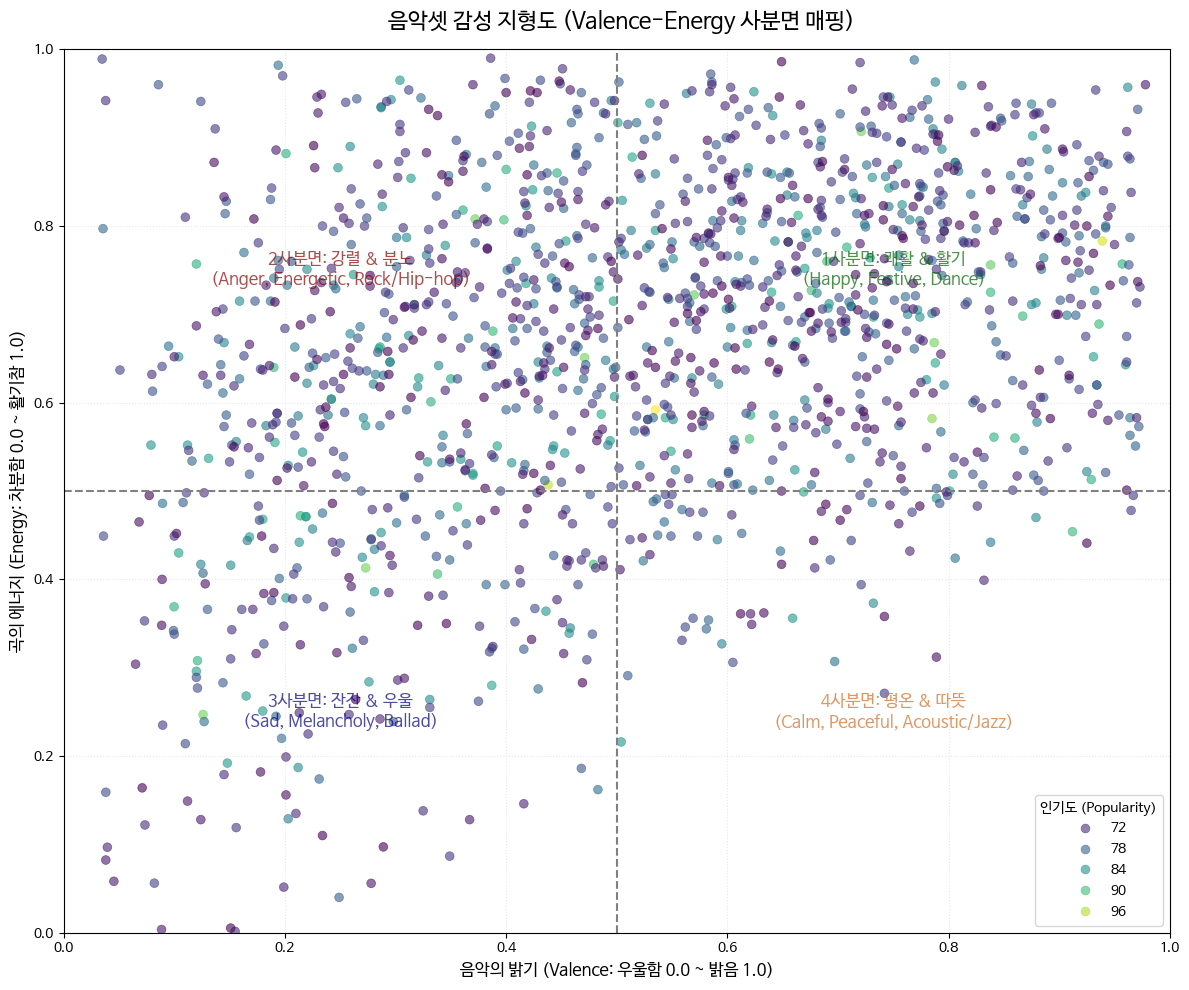

-----------------------------------------------------------------
📊 [음악셋 감성 사분면 분포 통계]
• 1사분면 (신나고 행복함) : 694개 (48.3%) | 평균 인기도: 75.19점
• 2사분면 (어둡고 강렬함) : 476개 (33.1%) | 평균 인기도: 75.44점
• 3사분면 (슬프고 우울함) : 196개 (13.6%) | 평균 인기도: 75.16점
• 4사분면 (평온하고 따뜻함) :  71개 (4.9%) | 평균 인기도: 74.80점
-----------------------------------------------------------------


In [26]:
# 1. 시각화를 위한 단독 프레임 생성
plt.figure(figsize=(12, 10))

# 2. 감성 매핑 산점도 그리기
# 점들이 겹쳐도 밀도를 알 수 있게 alpha(투명도)를 주어 표현하고, 인기도에 따라 색상 매핑
sns.scatterplot(
    data=df,
    x='valence',
    y='energy',
    hue='track_popularity',
    palette='viridis',
    alpha=0.6,
    edgecolor=None,
    s=40
)

# 3. 사분면을 나누는 기준선 설정 (Valence, Energy 모두 0.5가 중앙값/기준점)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1.5)

# 4. 각 사분면별 무드 영역 음영 처리 및 배경 텍스트 배치
# [1사분면] 우상단: 신나고 행복함
plt.text(0.75, 0.75, "1사분면: 쾌활 & 활기\n(Happy, Festive, Dance)",
         fontsize=12, color='darkgreen', weight='bold', ha='center', va='center', alpha=0.7)

# [2사분면] 좌상단: 어둡고 강렬함
plt.text(0.25, 0.75, "2사분면: 강렬 & 분노\n(Anger, Energetic, Rock/Hip-hop)",
         fontsize=12, color='darkred', weight='bold', ha='center', va='center', alpha=0.7)

# [3사분면] 좌하단: 슬프고 우울함
plt.text(0.25, 0.25, "3사분면: 잔잔 & 우울\n(Sad, Melancholy, Ballad)",
         fontsize=12, color='navy', weight='bold', ha='center', va='center', alpha=0.7)

# [4사분면] 우하단: 평화롭고 따뜻함
plt.text(0.75, 0.25, "4사분면: 평온 & 따뜻\n(Calm, Peaceful, Acoustic/Jazz)",
         fontsize=12, color='chocolate', weight='bold', ha='center', va='center', alpha=0.7)

# 5. 축 및 타이틀 레이아웃 설정
plt.title('🎵 음악셋 감성 지형도 (Valence-Energy 사분면 매핑)', fontsize=16, pad=15)
plt.xlabel('음악의 밝기 (Valence: 우울함 0.0 ~ 밝음 1.0)', fontsize=12)
plt.ylabel('곡의 에너지 (Energy: 차분함 0.0 ~ 활기참 1.0)', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle=':', alpha=0.3)

# 범례 위치 조정
plt.legend(title='인기도 (Popularity)', loc='lower right')

plt.tight_layout()
plt.show()

# --- 사분면별 실제 곡 수 및 비중 계산 데이터 리포트 ---
q1 = df[(df['valence'] >= 0.5) & (df['energy'] >= 0.5)]
q2 = df[(df['valence'] < 0.5) & (df['energy'] >= 0.5)]
q3 = df[(df['valence'] < 0.5) & (df['energy'] < 0.5)]
q4 = df[(df['valence'] >= 0.5) & (df['energy'] < 0.5)]
total = len(df)

print("-" * 65)
print("📊 [음악셋 감성 사분면 분포 통계]")
print(f"• 1사분면 (신나고 행복함) : {len(q1):3}개 ({len(q1)/total*100:.1f}%) | 평균 인기도: {q1['track_popularity'].mean():.2f}점")
print(f"• 2사분면 (어둡고 강렬함) : {len(q2):3}개 ({len(q2)/total*100:.1f}%) | 평균 인기도: {q2['track_popularity'].mean():.2f}점")
print(f"• 3사분면 (슬프고 우울함) : {len(q3):3}개 ({len(q3)/total*100:.1f}%) | 평균 인기도: {q3['track_popularity'].mean():.2f}점")
print(f"• 4사분면 (평온하고 따뜻함) : {len(q4):3}개 ({len(q4)/total*100:.1f}%) | 평균 인기도: {q4['track_popularity'].mean():.2f}점")
print("-" * 65)

인기도의 차이는 많이 없지만, 그래도 평온하고 따뜻한 노래의 인기도 다소 낮은 것을 알 수 있음

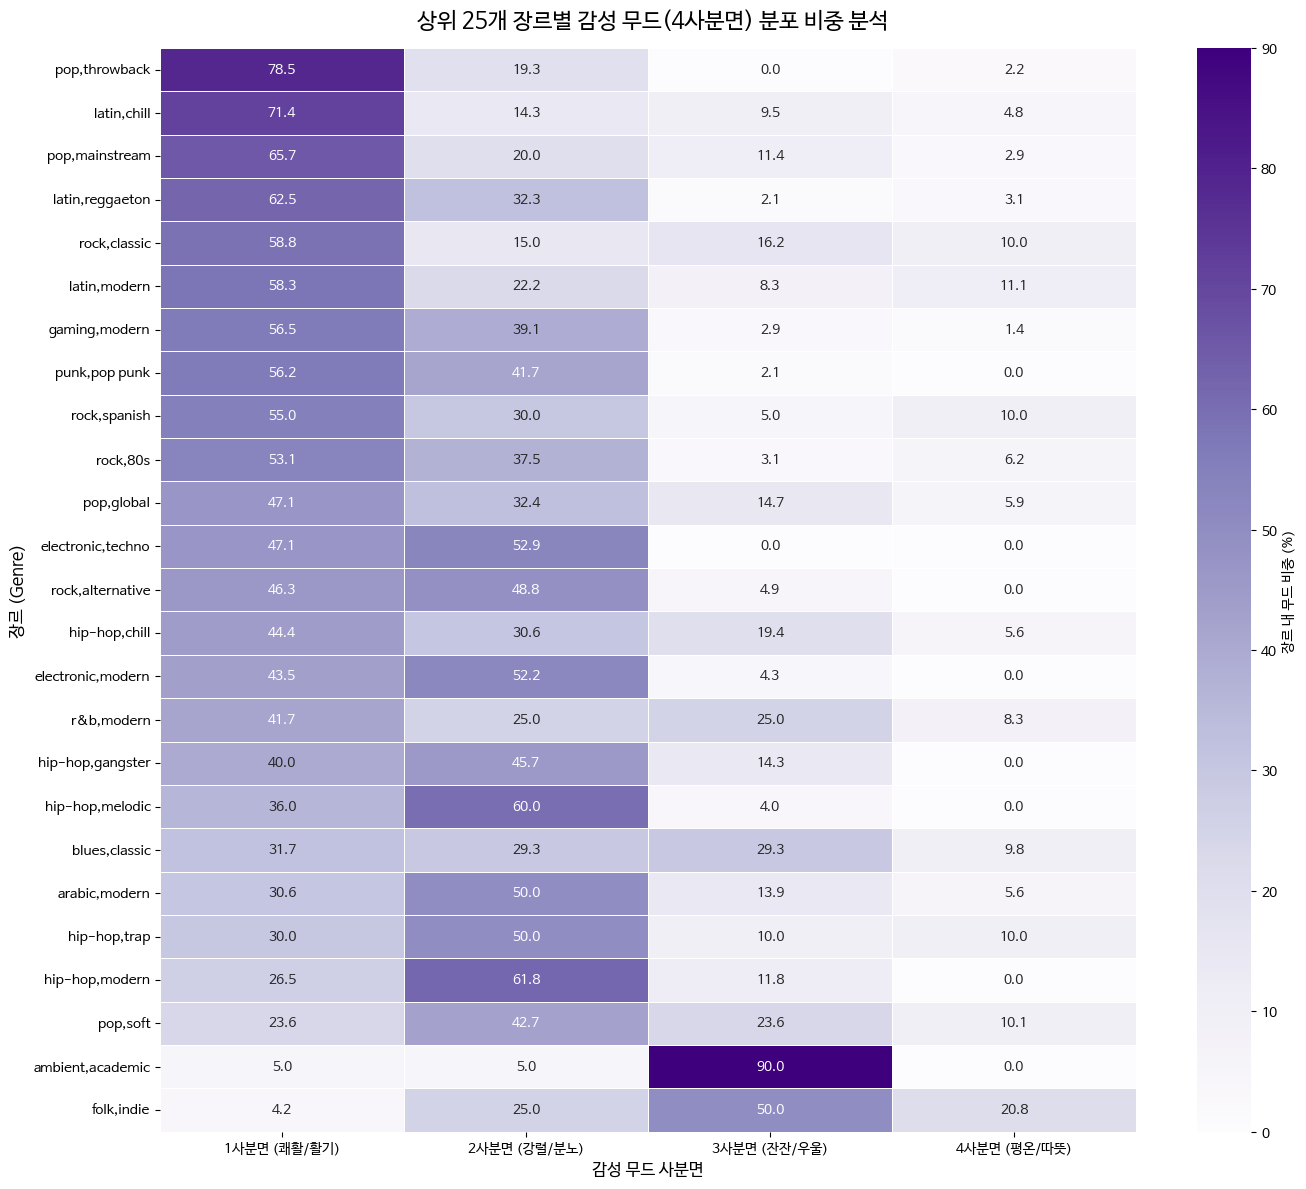

In [27]:
# 1. 기존 Valence와 Energy 기준을 바탕으로 4가지 무드(사분면) 범주화 파생 변수 생성
def get_mood_quadrant(row):
    if row['valence'] >= 0.5 and row['energy'] >= 0.5:
        return '1사분면 (쾌활/활기)'
    elif row['valence'] < 0.5 and row['energy'] >= 0.5:
        return '2사분면 (강렬/분노)'
    elif row['valence'] < 0.5 and row['energy'] < 0.5:
        return '3사분면 (잔잔/우울)'
    else:
        return '4사분면 (평온/따뜻)'

df['mood_quadrant'] = df.apply(get_mood_quadrant, axis=1)

# 2. 앞서 정의한 상위 25개 장르 데이터만 필터링
# (top_25_genres가 메모리에 없다면 다시 정의)
if 'top_25_genres' not in locals():
    top_25_genres = df['genre'].value_counts().head(25).index

df_top25 = df[df['genre'].isin(top_25_genres)]

# 3. 장르와 무드 사분면 간의 교차표(Crosstab) 생성
# 장르별 총합이 100%가 되도록 빈도를 비율(Percentage)로 변환 (normalize='index')
ct_mood = pd.crosstab(df_top25['genre'], df_top25['mood_quadrant'], normalize='index') * 100

# 보기 편하게 사분면 순서 정렬
quadrant_order = ['1사분면 (쾌활/활기)', '2사분면 (강렬/분노)', '3사분면 (잔잔/우울)', '4사분면 (평온/따뜻)']
ct_mood = ct_mood[quadrant_order]

# 장르 이름 기준(가나다/알파벳 순) 또는 특정 기준으로 정렬 가능
# 여기서는 1사분면(가장 신나는 무드) 비중이 높은 순서대로 장르를 정렬하여 내림차순 가독성 극대화
ct_mood = ct_mood.sort_values(by='1사분면 (쾌활/활기)', ascending=False)

# 4. 히트맵 시각화
plt.figure(figsize=(14, 12))
sns.heatmap(
    ct_mood,
    annot=True,          # 셀 내부에 실제 수치(%) 표시
    fmt=".1f",           # 소수점 첫째 자리까지 표기
    cmap='Purples',      # 보라색 톤의 고급스러운 컬러맵 적용
    linewidths=0.5,      # 셀 간의 경계선 두께
    cbar_kws={'label': '장르 내 무드 비중 (%)'}
)

plt.title('🎯 상위 25개 장르별 감성 무드(4사분면) 분포 비중 분석', fontsize=16, pad=15)
plt.xlabel('감성 무드 사분면', fontsize=12)
plt.ylabel('장르 (Genre)', fontsize=12)
plt.xticks(rotation=0) # X축 레이블 수평 유지

plt.tight_layout()
plt.show()

### 4.2 무드와 대중성(track_popularity)의 관계

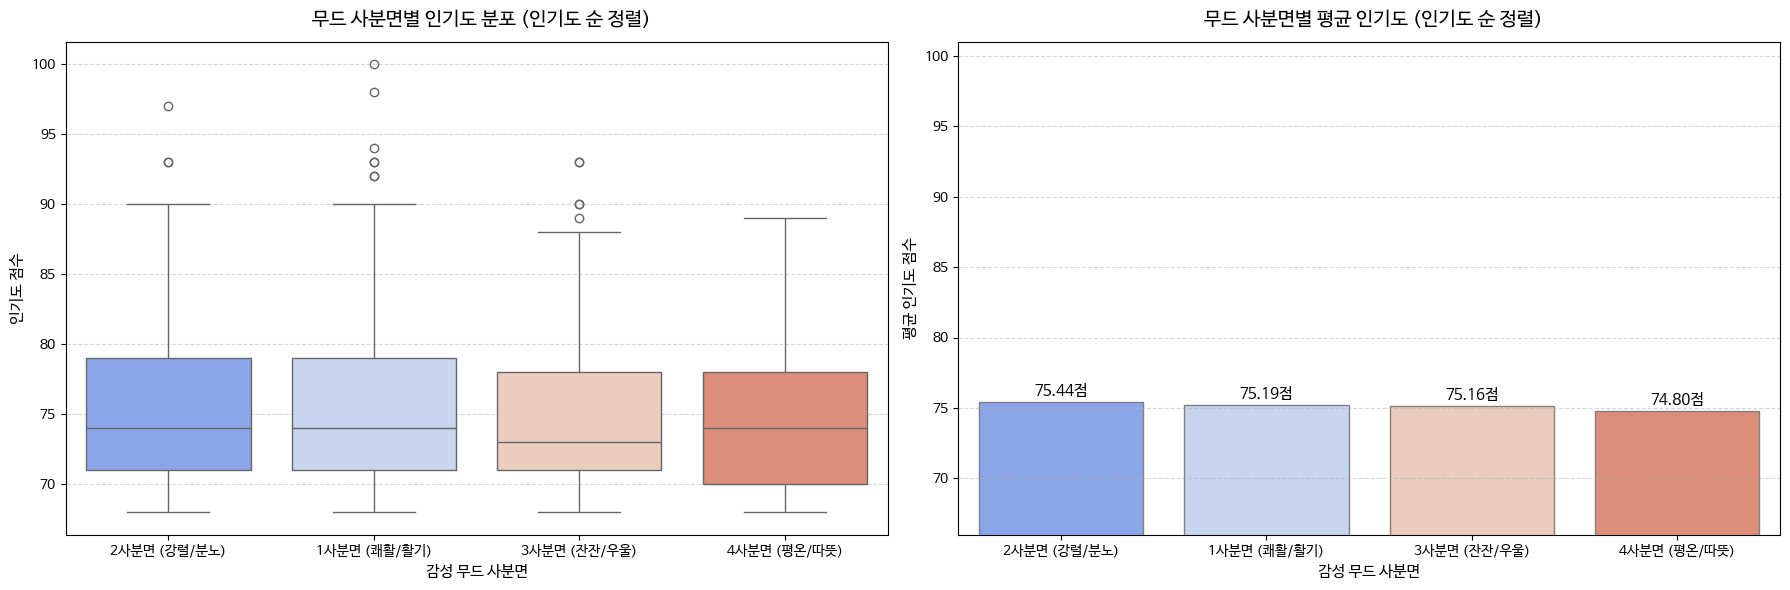

---------------------------------------------------------------------------
📈 [감성 무드별 대중성 지표 요약 리포트]
• 2사분면 (강렬/분노)    | 포함된 곡 수: 476개 | 평균 인기도: 75.44점
• 1사분면 (쾌활/활기)    | 포함된 곡 수: 694개 | 평균 인기도: 75.19점
• 3사분면 (잔잔/우울)    | 포함된 곡 수: 196개 | 평균 인기도: 75.16점
• 4사분면 (평온/따뜻)    | 포함된 곡 수:  71개 | 평균 인기도: 74.80점
---------------------------------------------------------------------------


In [28]:
# 1. 4가지 무드 사분면 정의 (이전 셀에서 지정한 변수가 없을 경우를 대비해 안전하게 재선언)
def get_mood_quadrant(row):
    if row['valence'] >= 0.5 and row['energy'] >= 0.5:
        return '1사분면 (쾌활/활기)'
    elif row['valence'] < 0.5 and row['energy'] >= 0.5:
        return '2사분면 (강렬/분노)'
    elif row['valence'] < 0.5 and row['energy'] < 0.5:
        return '3사분면 (잔잔/우울)'
    else:
        return '4사분면 (평온/따뜻)'

df['mood_quadrant'] = df.apply(get_mood_quadrant, axis=1)

# 시각적인 정렬 순서 고정
mood_order = ['1사분면 (쾌활/활기)', '2사분면 (강렬/분노)', '3사분면 (잔잔/우울)', '4사분면 (평온/따뜻)']

# 2. 각 무드별 평균 인기도를 구해 내림차순 정렬 순서 생성 (보는 입장에서 가장 편하게 정렬)
mood_pop_order = df.groupby('mood_quadrant')['track_popularity'].mean().sort_values(ascending=False).index

# 3. 시각화를 위한 1행 2열 프레임 생성
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# [왼쪽 그래프] 무드별 인기도 분포 (Boxplot) - 전체적인 데이터 퍼짐성과 이상치 확인
sns.boxplot(data=df, x='mood_quadrant', y='track_popularity', order=mood_pop_order, ax=axes[0], palette='coolwarm')
axes[0].set_title('📦 무드 사분면별 인기도 분포 (인기도 순 정렬)', fontsize=14, pad=12)
axes[0].set_xlabel('감성 무드 사분면', fontsize=11)
axes[0].set_ylabel('인기도 점수', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


# [오른쪽 그래프] 무드별 평균 인기도 비교 (Bar plot) - 직관적인 랭킹 확인
sns.barplot(data=df, x='mood_quadrant', y='track_popularity', order=mood_pop_order, ax=axes[1], palette='coolwarm', ci=None, edgecolor='gray')
axes[1].set_title('📊 무드 사분면별 평균 인기도 (인기도 순 정렬)', fontsize=14, pad=12)
axes[1].set_xlabel('감성 무드 사분면', fontsize=11)
axes[1].set_ylabel('평균 인기도 점수', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 차트 내에 평균 점수 텍스트 표시 및 Y축 범위 최적화
pop_min = df['track_popularity'].min()
axes[1].set_ylim(pop_min - 2, df['track_popularity'].max() + 1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}점', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 상세 통계 수치 및 무드별 곡 수 리포트 출력
print("-" * 75)
print("📈 [감성 무드별 대중성 지표 요약 리포트]")
for mood in mood_pop_order:
    sub_df = df[df['mood_quadrant'] == mood]
    print(f"• {mood:15} | 포함된 곡 수: {len(sub_df):3}개 | 평균 인기도: {sub_df['track_popularity'].mean():.2f}점")
print("-" * 75)

박스 플롯으로 이상치를 본 결과, 인기도의 평균은 비슷함. 그러나 평온한 노래가 평균은 가장 낮으나, 분포는 잔잔하고 우울한 노래가 더 밑인 것을 알 수 있었음

또한 이상치로 확인한 결과 가장 큰 히트작은 쾌활하고 활기찬 노래에서 나옴

## **5. 변수 간 상관관계 분석 (Correlation Analysis)**

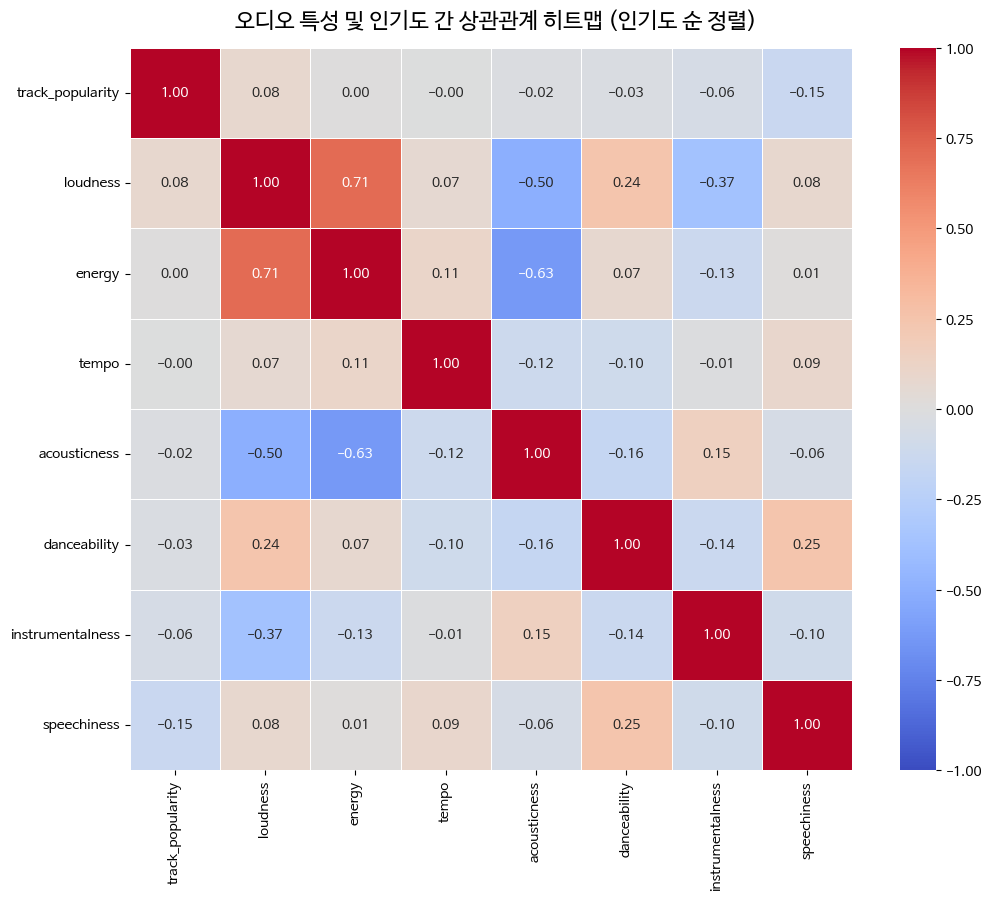

-----------------------------------------------------------------
🎯 [대중성(track_popularity)과의 주요 상관계수 랭킹]
track_popularity    1.000000
loudness            0.082717
energy              0.001345
tempo              -0.001993
acousticness       -0.021352
danceability       -0.025958
instrumentalness   -0.059188
speechiness        -0.146164
Name: track_popularity, dtype: float64
-----------------------------------------------------------------


In [29]:
# 1. 상관관계 분석에 사용할 수치형 오디오 피처 및 인기도 컬럼 선택
selected_features = [
    'track_popularity', 'energy', 'tempo', 'danceability',
    'loudness', 'speechiness', 'acousticness', 'instrumentalness'
]

# 선택한 변수들만 추출하여 상관관계 행렬(Correlation Matrix) 계산
corr_matrix = df[selected_features].corr()

# 2. 대중성(track_popularity) 기준 내림차순 정렬
# 행과 열을 인기도와 가장 상관관계가 높은 순서대로 재정렬하여 가독성 극대화
pop_corr_order = corr_matrix['track_popularity'].sort_values(ascending=False).index
corr_matrix_sorted = corr_matrix.loc[pop_corr_order, pop_corr_order]

# 3. 시각화 프레임 생성
plt.figure(figsize=(11, 9))

# 4. 히트맵 그리기
# 0(상관없음)을 기준으로 양수와 음수가 대비되도록 발산형(Diverging) 컬러맵 'coolwarm' 적용
sns.heatmap(
    corr_matrix_sorted,
    annot=True,           # 셀 내부에 상관계수 수치 표시
    fmt=".2f",            # 소수점 둘째 자리까지 표기
    cmap='coolwarm',      # 양수는 빨간색, 음수는 파란색, 0은 흰색/연회색
    vmin=-1.0, vmax=1.0,  # 상관계수 한계치 고정 (-1에서 1)
    linewidths=0.5,       # 셀 사이 경계선
    square=True           # 셀을 정사각형 모양으로 고정
)

plt.title('📊 오디오 특성 및 인기도 간 상관관계 히트맵 (인기도 순 정렬)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

# 5. 인기도 기준의 상관계수만 따로 요약 리포트 출력
print("-" * 65)
print("🎯 [대중성(track_popularity)과의 주요 상관계수 랭킹]")
print(corr_matrix['track_popularity'].sort_values(ascending=False))
print("-" * 65)